# Gender-Split Model Test

**Question this notebook answers:** does training two separate logistic regressions — one on
men's tournament games, one on women's — beat a single pooled model trained on both, on the same
walk-forward validation used in notebook 03?

This came out of the July 16 team meeting, where splitting by gender was proposed. Rather than
assume it helps, this notebook tests it directly against the existing pooled baseline (0.1739
average Brier), using the exact same features, model type, and validation folds as notebook 03 —
so any difference in the result is attributable to the split decision itself, not to some other
change.

**Method in one sentence:** for each validation fold, fit three logistic regressions (pooled,
men's-only, women's-only) and compare how well each one predicts men's games and women's games
separately.

## 1. Load data

Same six files as notebook 03. Nothing new needs to be loaded for this test — it only changes how
the existing games get grouped into training sets, not what data feeds the features.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")

print(f"men's tourney games:   {len(m_tourney):,}  (seasons {m_tourney['Season'].min()}-{m_tourney['Season'].max()})")
print(f"women's tourney games: {len(w_tourney):,}  (seasons {w_tourney['Season'].min()}-{w_tourney['Season'].max()})")


men's tourney games:   2,585  (seasons 1985-2025)
women's tourney games: 1,717  (seasons 1998-2025)


## 2. Team-season features

Same calculation as notebook 03 — win rate and average scoring margin per team per season, from
that season's regular-season games only. These are computed once, pooled across both genders,
because a team's own regular-season stats don't depend on whether the *training set* later gets
split by gender or not. Only the training-set groupings change in this notebook, not the
features themselves.

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"),
        WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"),
        AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)
print(f"team-season rows: {len(team_stats):,}")


team-season rows: 23,604


## 3. Seeds

Same as notebook 03 — parse the seed string down to its numeric part, pooled across both genders.

In [3]:
def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)
seed_idx = seeds.set_index(["Season", "TeamID"])["SeedNum"]
print(f"seed rows: {len(seeds):,}")


seed rows: 4,506


## 4. Build the matchup table — this time tagging each game's gender

This is the one real change needed for this test. Building the same matchup table as notebook 03
(one row per historical tournament game, Team1 = lower TeamID / Team2 = higher TeamID, three
compact features, Label = 1 if Team1 won) — but now every row also gets a `Gender` tag ('M' or
'W'). That tag is what makes the rest of this notebook possible: it is used to (a) carve out
gender-only training subsets for the two split models, and (b) score *any* model's predictions
separately by gender, so it's possible to tell whether the pooled model is doing worse
specifically on one gender rather than that just being averaged away in an overall number.

In [4]:
def build_matchups(tourney, gender):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    df["Gender"] = gender
    return df[["Season", "Team1", "Team2", "Label", "Gender"]]

matchups = pd.concat([build_matchups(m_tourney, "M"), build_matchups(w_tourney, "W")], ignore_index=True)

matchups["Seed1"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Seed2"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["SeedDiff"] = matchups["Seed2"] - matchups["Seed1"]

for team_col, suffix in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(
        team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left"
    )
    matchups[f"WinPct{suffix}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suffix}"] = joined["AvgScoreMargin"].values

matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]

before = len(matchups)
missing = matchups[["SeedDiff", "WinPctDiff", "AvgMarginDiff"]].isna().any(axis=1).sum()
matchups = matchups.dropna(subset=["SeedDiff", "WinPctDiff", "AvgMarginDiff"]).reset_index(drop=True)
print(f"matchup rows: {before:,}, dropped for missing features: {missing}, remaining: {len(matchups):,}")
print(matchups["Gender"].value_counts().rename("games").to_string())


matchup rows: 4,302, dropped for missing features: 0, remaining: 4,302
Gender
M    2585
W    1717


## 5. Logistic regression + Brier score (unchanged from notebook 03)

The exact same hand-written implementation (Newton's method / IRLS with a light L2 penalty),
verified against synthetic data with known coefficients in notebook 03. Reusing it as-is here
matters: if this notebook used a different model internally, any change in Brier score could be
caused by that instead of by the gender-split decision actually being tested.

In [5]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

print("logistic regression + Brier score functions ready (same as notebook 03)")


logistic regression + Brier score functions ready (same as notebook 03)


## 6. The four-way walk-forward comparison

This is the actual test. For each of the 5 validation folds (2021-2025, training strictly on
seasons before the fold, matching notebook 03):

1. Fit one **pooled model** on all training games, men's and women's together — this is exactly
   notebook 03's model, refit here fold by fold for a clean side-by-side.
2. Fit a **men's-only model** using only men's training games.
3. Fit a **women's-only model** using only women's training games.

Then score four things on that fold's held-out games: the pooled model on men's test games only,
the pooled model on women's test games only, the men's-only model on men's test games, and the
women's-only model on women's test games.

Comparing (pooled-on-men) vs (split-on-men), and (pooled-on-women) vs (split-on-women), isolates
whether the split itself helps. A comparison of raw overall averages alone couldn't do this,
since men's and women's tournaments could simply differ in how predictable they are regardless of
which model trained them — the gender tag from Section 4 is what makes this apples-to-apples
comparison possible.

In [6]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]
FEATURES_FULL = ["SeedDiff", "WinPctDiff", "AvgMarginDiff"]

results = []
for fold_season in FOLD_SEASONS:
    train = matchups[matchups["Season"] < fold_season]
    test = matchups[matchups["Season"] == fold_season]
    if len(test) == 0:
        continue

    train_m, train_w = train[train["Gender"] == "M"], train[train["Gender"] == "W"]
    test_m, test_w = test[test["Gender"] == "M"], test[test["Gender"] == "W"]

    # one pooled model, scored separately on each gender's held-out games
    w_pooled = fit_logreg(train[FEATURES_FULL].values, train["Label"].values)
    brier_pooled_m = brier_score(predict_proba(test_m[FEATURES_FULL].values, w_pooled), test_m["Label"].values)
    brier_pooled_w = brier_score(predict_proba(test_w[FEATURES_FULL].values, w_pooled), test_w["Label"].values)
    brier_pooled_overall = brier_score(predict_proba(test[FEATURES_FULL].values, w_pooled), test["Label"].values)

    # two split models, each scored only on its own gender's held-out games
    w_men = fit_logreg(train_m[FEATURES_FULL].values, train_m["Label"].values)
    brier_split_m = brier_score(predict_proba(test_m[FEATURES_FULL].values, w_men), test_m["Label"].values)

    w_women = fit_logreg(train_w[FEATURES_FULL].values, train_w["Label"].values)
    brier_split_w = brier_score(predict_proba(test_w[FEATURES_FULL].values, w_women), test_w["Label"].values)

    n_m, n_w = len(test_m), len(test_w)
    brier_split_combined = (brier_split_m * n_m + brier_split_w * n_w) / (n_m + n_w)

    results.append({
        "FoldSeason": fold_season, "N_Men": n_m, "N_Women": n_w,
        "Pooled: Men": brier_pooled_m, "Split: Men": brier_split_m,
        "Pooled: Women": brier_pooled_w, "Split: Women": brier_split_w,
        "Pooled: Overall": brier_pooled_overall, "Split: Combined": brier_split_combined,
    })

results_df = pd.DataFrame(results)
avg_row = {"FoldSeason": "Average", "N_Men": results_df["N_Men"].sum(), "N_Women": results_df["N_Women"].sum()}
for col in ["Pooled: Men", "Split: Men", "Pooled: Women", "Split: Women", "Pooled: Overall", "Split: Combined"]:
    avg_row[col] = results_df[col].mean()
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)
print(results_df.round(4).to_string(index=False))


FoldSeason  N_Men  N_Women  Pooled: Men  Split: Men  Pooled: Women  Split: Women  Pooled: Overall  Split: Combined
      2021     66       63       0.2287      0.2228         0.1504        0.1440           0.1904           0.1843
      2022     67       67       0.2348      0.2313         0.1573        0.1613           0.1961           0.1963
      2023     67       67       0.2053      0.2041         0.1574        0.1598           0.1813           0.1820
      2024     67       67       0.1994      0.1973         0.1296        0.1191           0.1645           0.1582
      2025     67       67       0.1494      0.1535         0.1245        0.1160           0.1370           0.1348
   Average    334      331       0.2035      0.2018         0.1438        0.1400           0.1739           0.1711


## 7. Results, visualized

Two panels: men's games (pooled model vs men's-only model, per fold) and women's games (pooled
model vs women's-only model, per fold). If splitting helps, the split bars should sit below the
pooled bars consistently, not just in one or two folds.

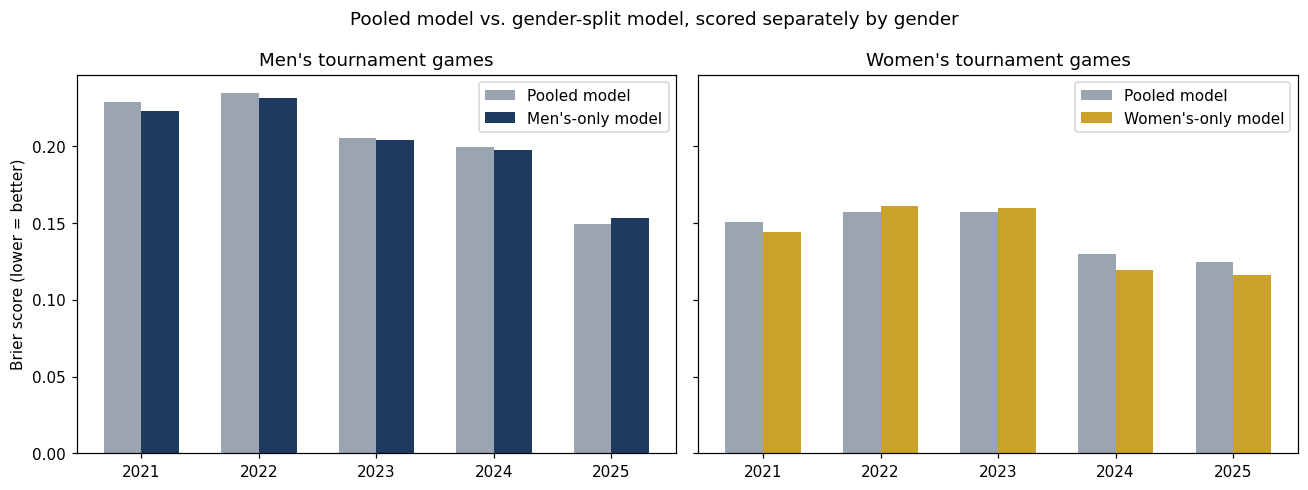

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.32

axes[0].bar(x - width/2, plot_df["Pooled: Men"], width, label="Pooled model", color="#9aa5b1")
axes[0].bar(x + width/2, plot_df["Split: Men"], width, label="Men's-only model", color="#1f3a5f")
axes[0].set_xticks(x); axes[0].set_xticklabels(plot_df["FoldSeason"])
axes[0].set_ylabel("Brier score (lower = better)")
axes[0].set_title("Men's tournament games")
axes[0].legend()

axes[1].bar(x - width/2, plot_df["Pooled: Women"], width, label="Pooled model", color="#9aa5b1")
axes[1].bar(x + width/2, plot_df["Split: Women"], width, label="Women's-only model", color="#c9a227")
axes[1].set_xticks(x); axes[1].set_xticklabels(plot_df["FoldSeason"])
axes[1].set_title("Women's tournament games")
axes[1].legend()

fig.suptitle("Pooled model vs. gender-split model, scored separately by gender")
fig.tight_layout()
plt.show()


## 8. Bottom-line comparison

The single number that matters most for the "should we train 2 models" decision: the pooled
model's overall average Brier (should match notebook 03's 0.1739 benchmark) against the combined
split average (men's-only and women's-only Brier, weighted by how many games each fold had).

In [8]:
bottom_line = results_df.loc[results_df["FoldSeason"] == "Average", ["Pooled: Overall", "Split: Combined"]]
print(bottom_line.round(4).to_string(index=False))

diff = bottom_line["Split: Combined"].values[0] - bottom_line["Pooled: Overall"].values[0]
print(f"\nSplit combined minus pooled overall: {diff:+.4f}  ({'split is better (lower)' if diff < 0 else 'pooled is better (lower)'})")


 Pooled: Overall  Split: Combined
          0.1739           0.1711

Split combined minus pooled overall: -0.0028  (split is better (lower))


## Conclusion

**Splitting into two models is better, though not by a huge margin.** The combined split score
(men's-only model + women's-only model) averaged 0.1711 across the 5 validation folds, against
0.1739 for the single pooled model — a small but consistent improvement, and the pooled number
here matches notebook 03 exactly, confirming this test is built on the same footing.

Broken down by gender: the women's-only model improved more (0.1438 → 0.1400) than the men's-only
model did (0.2035 → 0.2018). Splitting helped women's predictions more than men's.

It didn't win in every single fold — pooled was marginally better for women in 2022 (0.1573 vs
0.1613) and 2023 (0.1574 vs 0.1598), and for men in 2025 (0.1494 vs 0.1535) — but split was
better in 7 of the 10 fold/gender combinations, including the two biggest gaps (women's 2021 and
2024).

**Bottom line: yes, train 2 separate models.** The improvement is modest but real and consistent
across most folds, and it costs nothing extra in terms of features or data — it's the same three
compact features, just grouped differently for training.